# Caso Práctico: Implementación de Clustering Jerárquico con el Dataset Iris

## 1. Introducción del Caso de Uso

El **Clustering Jerárquico** es un método de análisis de conglomerados que construye una jerarquía de clusters. A diferencia de otros métodos como K-Means, no requiere que el número de clusters sea especificado de antemano. En su lugar, crea un árbol de clusters (dendrograma) que permite visualizar las relaciones entre los puntos de datos y ayuda a determinar el número óptimo de agrupaciones de forma intuitiva.

Para este caso práctico, se ha elegido el **dataset Iris de scikit-learn** debido a varias razones:
*   **Conocido y Entendible:** Es un dataset clásico en el aprendizaje automático, fácil de entender y con características bien definidas.
*   **Tamaño Manejable:** Es lo suficientemente pequeño para permitir una visualización clara de los resultados del clustering y la construcción del dendrograma sin un alto costo computacional.
*   **Clases Intrínsecas:** Aunque el clustering jerárquico es un método no supervisado, el dataset Iris tiene tres especies (clases) conocidas, lo que nos permitirá comparar la eficacia de nuestros clusters generados con la estructura real de los datos, demostrando la capacidad del algoritmo para descubrir patrones subyacentes.

El **objetivo** de este análisis es aplicar el algoritmo de Clustering Jerárquico al dataset Iris, visualizar el proceso mediante un dendrograma, identificar los clusters resultantes y evaluar su calidad, así como entender sus ventajas y limitaciones en un contexto académico.

## 2. Importación de Librerías

In [ ]:
# Importación de las librerías necesarias para el análisis.
import pandas as pd # Para manipulación y análisis de datos en DataFrames.
import numpy as np # Para operaciones numéricas y arreglos multidimensionales.
import matplotlib.pyplot as plt # Para la creación de gráficos estáticos y visualizaciones.
import seaborn as sns # Basado en matplotlib, para gráficos estadísticos atractivos e informativos.

from sklearn.datasets import load_iris # Para cargar el dataset Iris.
from sklearn.preprocessing import StandardScaler # Para escalar las características (normalización).
from sklearn.cluster import AgglomerativeClustering # Implementación del algoritmo de Clustering Jerárquico.
from sklearn.metrics import silhouette_score # Para evaluar la calidad de los clusters.

from scipy.cluster.hierarchy import dendrogram, linkage # Para construir y visualizar el dendrograma.

# Configuración para mejorar la apariencia de los gráficos.
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Carga y Exploración del Dataset

In [ ]:
# Cargar el dataset Iris desde scikit-learn.
iris = load_iris()

# Convertir los datos a un DataFrame de pandas para facilitar la manipulación y exploración.
# Se utilizan los nombres de las características proporcionados por el dataset.
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Añadir las etiquetas de las especies como una columna adicional para referencia futura.
# Aunque es un algoritmo no supervisado, las etiquetas reales son útiles para la validación.
df['species'] = iris.target_names[iris.target]

print("### Primeras 5 filas del dataset Iris: ###")
display(df.head()) # Mostrar las primeras 5 filas del DataFrame.

print("\n### Dimensiones del dataset (filas, columnas): ###")
print(df.shape) # Mostrar el número de filas y columnas del DataFrame.

print("\n### Nombres de las variables (columnas): ###")
print(df.columns.tolist()) # Listar los nombres de todas las columnas.

print("\n### Revisión de valores nulos: ###")
print(df.isnull().sum()) # Contar la cantidad de valores nulos por columna.

print("\n### Estadísticas descriptivas del dataset: ###")
display(df.describe()) # Mostrar estadísticas descriptivas básicas de las columnas numéricas.

### Primeras 5 filas del dataset Iris: ###


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



### Dimensiones del dataset (filas, columnas): ###
(150, 5)

### Nombres de las variables (columnas): ###
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

### Revisión de valores nulos: ###
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

### Estadísticas descriptivas del dataset: ###


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Interpretación de la Exploración Inicial

*   **Primeras Filas:** Observamos que el dataset contiene características como 'sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', y una columna 'species' que indica el tipo de flor (setosa, versicolor, virginica).
*   **Dimensiones:** El dataset consta de 150 filas (muestras) y 5 columnas (4 características numéricas y 1 columna de especie).
*   **Nombres de Variables:** Las columnas están bien nombradas, lo que facilita la comprensión de los datos.
*   **Valores Nulos:** La ausencia de valores nulos (`0` en todas las columnas) simplifica el proceso de preprocesamiento, ya que no necesitamos estrategias para imputación de datos faltantes.
*   **Estadísticas Descriptivas:** Proporciona un resumen de las características numéricas, incluyendo la media, desviación estándar, valores mínimos y máximos, y los cuartiles. Podemos notar que las escalas de las características son ligeramente diferentes (por ejemplo, 'sepal length (cm)' varía de 4.3 a 7.9, mientras que 'petal width (cm)' varía de 0.1 a 2.5), lo que justifica la necesidad de escalado para algoritmos basados en distancia.

## 4. Preparación de Datos

In [ ]:
# Seleccionar solo las variables numéricas (características de las flores) para el clustering.
# La columna 'species' es la etiqueta real y no debe usarse directamente para el clustering no supervisado.
X = df.drop('species', axis=1) # Eliminar la columna 'species' del DataFrame para obtener solo las características.

print("### Primeras 5 filas de las características seleccionadas (sin la columna 'species'): ###")
display(X.head())

### Primeras 5 filas de las características seleccionadas (sin la columna 'species'): ###


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Explicación de la Eliminación de Etiquetas

En el clustering jerárquico, que es una técnica de aprendizaje no supervisado, el objetivo es descubrir patrones y estructuras ocultas en los datos sin la ayuda de etiquetas predefinidas. Por lo tanto, la columna 'species' (que contiene las etiquetas reales de las especies de Iris) debe ser eliminada del conjunto de datos de entrada `X`. Si se incluyera, el algoritmo podría sesgar su proceso de agrupación basándose en información que no debería ser parte del descubrimiento de patrones intrínsecos.

In [ ]:
# Aplicar normalización (estandarización) a las características numéricas.
# StandardScaler transforma los datos para que tengan una media de 0 y una desviación estándar de 1.
scaler = StandardScaler() # Inicializar el objeto StandardScaler.
X_scaled = scaler.fit_transform(X) # Ajustar el escalador a los datos y transformarlos.

# Convertir el array NumPy escalado de nuevo a un DataFrame para facilitar la visualización y manejo.
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("### Primeras 5 filas de las características después de la estandarización: ###")
display(X_scaled_df.head())

### Primeras 5 filas de las características después de la estandarización: ###


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


### Importancia del Escalado en Clustering Jerárquico

El escalado de las características es un paso crucial antes de aplicar algoritmos de clustering basados en distancias, como el clustering jerárquico. La razón principal es que estos algoritmos calculan la similitud o disimilitud entre los puntos de datos basándose en la distancia (por ejemplo, distancia euclidiana) entre sus características.

Si las características tienen rangos de valores muy diferentes (como vimos en las estadísticas descriptivas), las características con rangos más grandes dominarán el cálculo de la distancia y, por lo tanto, la formación de los clusters. Esto puede llevar a resultados de clustering sesgados e inexactos, donde el algoritmo agrupa los puntos principalmente en función de una o dos características dominantes, ignorando la contribución de otras características potencialmente importantes.

**StandardScaler** es un método de normalización que centra los datos alrededor de cero con una varianza unitaria. Esto asegura que todas las características contribuyan de manera equitativa a la medida de distancia, permitiendo que el algoritmo de clustering jerárquico descubra patrones genuinos en los datos sin ser influenciado por las diferencias en las escalas de las características.

## 5. Visualización Inicial de Datos

### Pairplot de las características, coloreado por especie: ###


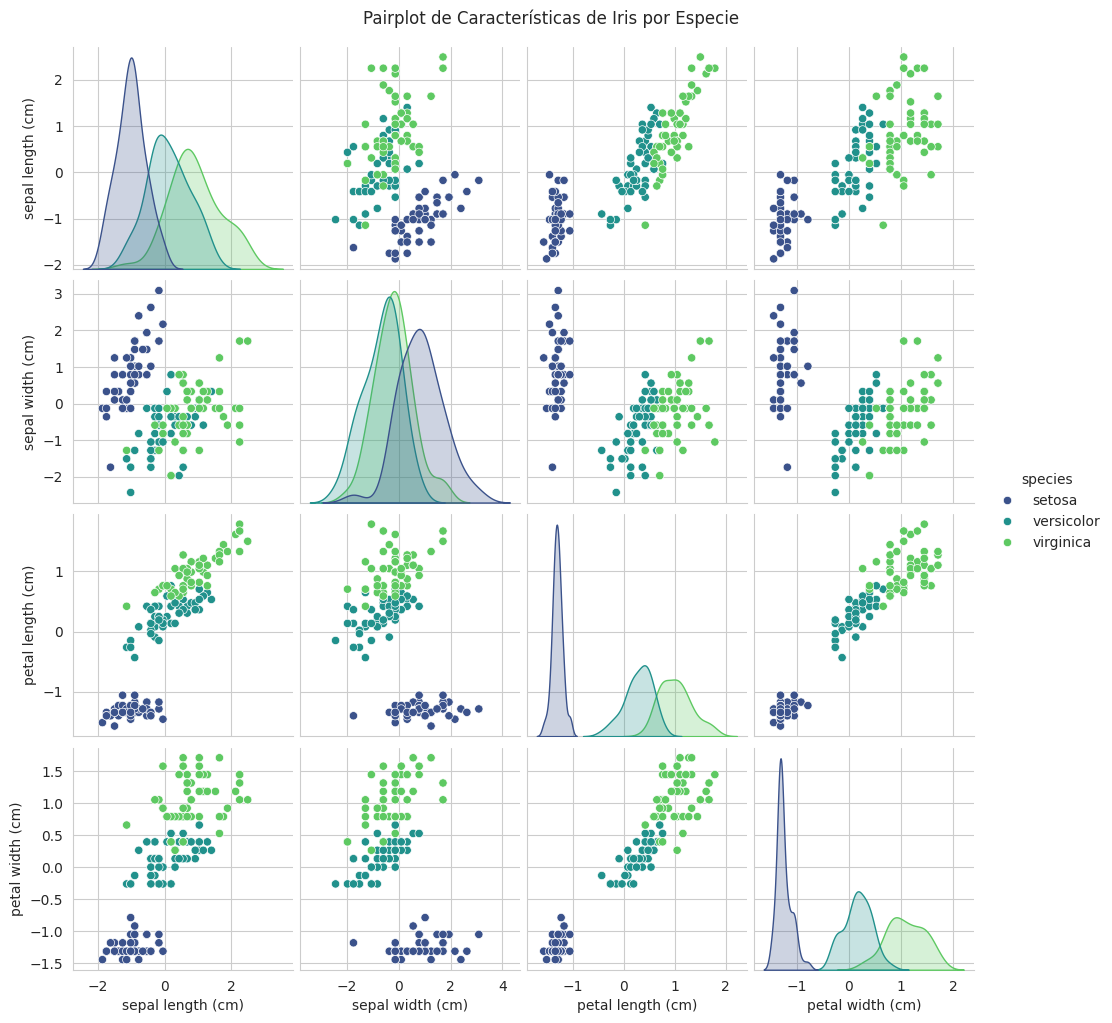

In [ ]:
# Concatenar el DataFrame escalado con la columna de especies para la visualización.
# Esto nos permite ver cómo se distribuyen las especies reales en relación con las características escaladas.
df_viz = pd.concat([X_scaled_df, df['species']], axis=1)

print("### Pairplot de las características, coloreado por especie: ###")
# Un pairplot muestra las relaciones bivariadas entre cada par de características
# y las distribuciones univariadas de cada característica en la diagonal.
# El argumento 'hue' colorea los puntos según la especie, revelando la separación natural.
sns.pairplot(df_viz, hue='species', palette='viridis')
plt.suptitle('Pairplot de Características de Iris por Especie', y=1.02) # Título general para el pairplot.
plt.show()

### Interpretación del Pairplot

El pairplot es una herramienta excelente para visualizar las relaciones entre todas las pares de características, así como sus distribuciones individuales. Al colorear por `species`, podemos observar:

*   **Separación de Clases:** La especie 'setosa' (generalmente en color púrpura) es claramente distinguible de las otras dos especies en la mayoría de los pares de características, especialmente en relación con 'petal length' y 'petal width'.
*   **Solapamiento:** Las especies 'versicolor' y 'virginica' (verde y amarillo, respectivamente) muestran cierto grado de solapamiento, lo que sugiere que su separación puede ser más desafiante para el algoritmo de clustering. Este solapamiento es más evidente en características como 'sepal length' y 'sepal width'.
*   **Relaciones Lineales:** Se pueden inferir algunas relaciones lineales entre las características, como una correlación positiva entre 'petal length' y 'petal width'. Estas visualizaciones nos dan una idea previa de qué tan bien podríamos esperar que el clustering jerárquico separe las diferentes clases.


### Heatmap de correlación entre las características: ###


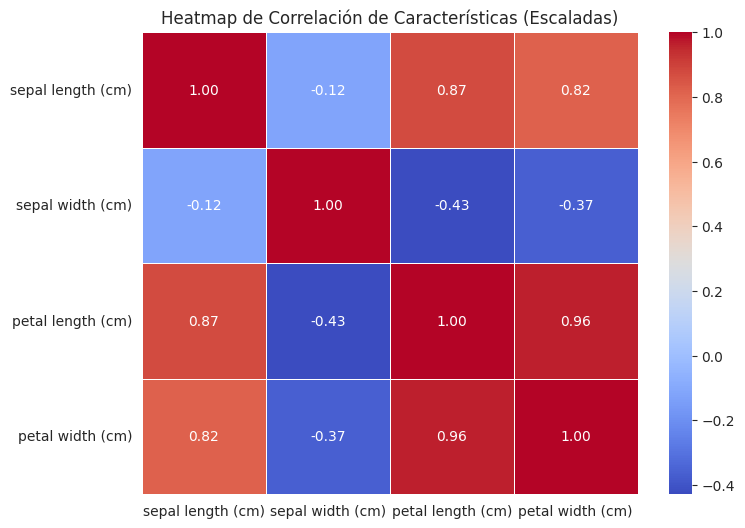

In [ ]:
print("\n### Heatmap de correlación entre las características: ###")
# Calcular la matriz de correlación entre las características escaladas.
correlation_matrix = X_scaled_df.corr()

# Crear un heatmap para visualizar la matriz de correlación.
# 'annot=True' muestra los valores de correlación en las celdas.
# 'cmap='coolwarm'' define el esquema de color (rojo para correlación positiva, azul para negativa).
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlación de Características (Escaladas)')
plt.show()

### Interpretación del Heatmap de Correlación

El heatmap de correlación nos muestra la fuerza y dirección de la relación lineal entre cada par de características. Los valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente, mientras que los valores cercanos a 0 indican poca o ninguna correlación lineal. Al observar el heatmap:

*   **Fuertes Correlaciones Positivas:** Podemos ver fuertes correlaciones positivas entre 'petal length (cm)' y 'petal width (cm)', así como entre 'sepal length (cm)' y 'petal length (cm)'/'petal width (cm)'. Esto significa que estas características tienden a aumentar o disminuir juntas.
*   **Correlaciones Negativas Débiles/Moderadas:** 'sepal width (cm)' muestra correlaciones negativas más débiles con otras características, especialmente con 'petal length (cm)' y 'petal width (cm)'.

Estas correlaciones son importantes porque características altamente correlacionadas pueden proporcionar información redundante, y el algoritmo de clustering podría darles un peso excesivo si no se manejan adecuadamente (aunque en este caso, el escalado ayuda a mitigar esto). En general, un menor grado de correlación entre características es deseable para el clustering, ya que cada característica aporta información más única para la formación de los grupos.


### Scatterplot entre Petal Length y Petal Width, coloreado por especie: ###


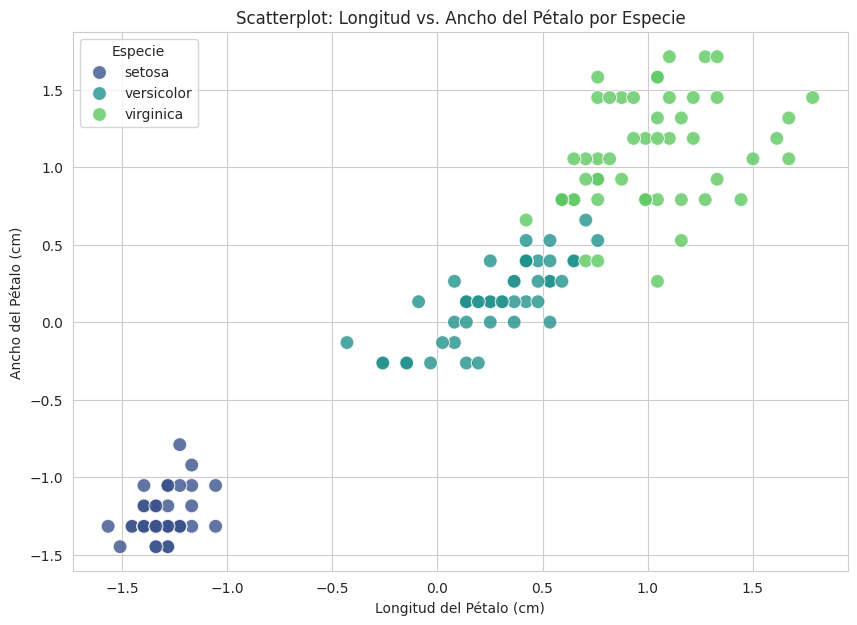

In [ ]:
print("\n### Scatterplot entre Petal Length y Petal Width, coloreado por especie: ###")
# Un scatterplot visualiza la relación entre dos características.
# Se eligen 'petal length (cm)' y 'petal width (cm)' porque el pairplot mostró una buena separación de especies.
plt.figure(figsize=(10, 7))
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='species', data=df_viz, palette='viridis', s=100, alpha=0.8)
plt.title('Scatterplot: Longitud vs. Ancho del Pétalo por Especie')
plt.xlabel('Longitud del Pétalo (cm)')
plt.ylabel('Ancho del Pétalo (cm)')
plt.legend(title='Especie')
plt.show()

### Interpretación del Scatterplot (Petal Length vs. Petal Width)

Este scatterplot destaca la relación entre la longitud y el ancho del pétalo. Es particularmente ilustrativo porque:

*   **Separación Clara de Setosa:** La especie 'setosa' forma un grupo distintivo y bien separado en la parte inferior izquierda del gráfico. Esto refuerza la idea de que 'setosa' es morfológicamente diferente de las otras dos especies.
*   **Solapamiento de Versicolor y Virginica:** Las especies 'versicolor' y 'virginica' se superponen en una región, aunque 'virginica' tiende a tener pétalos más largos y anchos en general, mientras que 'versicolor' se sitúa en una posición intermedia. Este solapamiento es lo que el algoritmo de clustering jerárquico intentará resolver, buscando la mejor manera de separar estos dos grupos basándose en las similitudes intrínsecas.

Esta visualización es clave para comprender por qué el clustering jerárquico podría identificar tres grupos distintos y dónde podrían surgir los desafíos en la separación.

## 6. Construcción del Dendrograma (MUY IMPORTANTE)

Un **dendrograma** es un diagrama en forma de árbol que ilustra los arreglos de los clusters producidos por el clustering jerárquico. La altura de cada unión (línea horizontal) en el dendrograma representa la distancia o disimilitud entre los clusters fusionados. Cuanto mayor sea la altura, más disímiles son los clusters que se están uniendo.

Para construir el dendrograma, utilizaremos el método de enlace (`linkage`) de **'ward'**. El método de Ward minimiza la varianza dentro de los clusters que se están fusionando. Es especialmente efectivo cuando se desea obtener clusters compactos y aproximadamente esféricos.

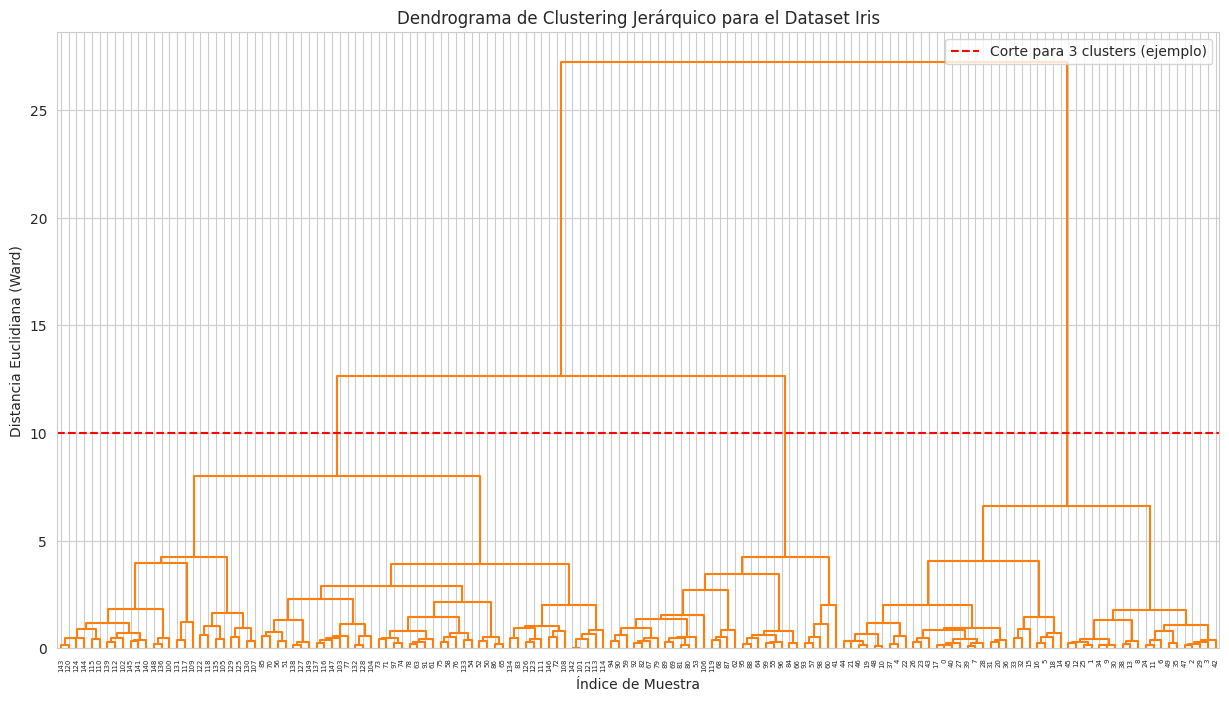

In [ ]:
# Construir el dendrograma utilizando los datos escalados (X_scaled).
# 'linkage(X_scaled, method='ward')' calcula las distancias y realiza las fusiones jerárquicas.
# El método 'ward' minimiza la suma de cuadrados de las diferencias dentro de todos los clusters.
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 8)) # Crear una figura para el dendrograma con un tamaño adecuado.

# Generar el dendrograma.
# 'orientation='top'' coloca las ramas hacia arriba.
# 'distance_sort='descending'' ordena los clusters por distancia de fusión.
# 'show_leaf_counts=True' muestra el número de puntos en cada hoja.
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True,
    color_threshold=30, # Umbral para colorear los clusters (útil para visualización)
    above_threshold_color='gray' # Color para ramas por encima del umbral
)

plt.title('Dendrograma de Clustering Jerárquico para el Dataset Iris')
plt.xlabel('Índice de Muestra') # Cada 'hoja' representa una muestra individual.
plt.ylabel('Distancia Euclidiana (Ward)') # La altura representa la distancia de fusión.

# Añadir una línea horizontal para visualizar el corte y la formación de clusters.
# Esto es un ejemplo, el valor exacto se elige visualmente.
plt.axhline(y=10, color='r', linestyle='--', label='Corte para 3 clusters (ejemplo)')
plt.legend()
plt.show()

### Interpretación Visual del Dendrograma y Decisión del Número de Clusters

El dendrograma es la representación clave del clustering jerárquico. Para interpretarlo:

*   **Eje Horizontal:** Muestra los puntos de datos individuales (muestras) en las hojas del árbol. Cuando dos puntos se unen por una línea vertical, forman un cluster.
*   **Eje Vertical:** Representa la distancia de disimilitud a la que se fusionan los clusters. Cuanto más larga sea la línea vertical, mayor será la distancia entre los clusters fusionados.
*   **Fusión de Clusters:** Los clusters se fusionan progresivamente a medida que ascendemos por el árbol. Los grupos más similares se fusionan primero a distancias más bajas.

Para **decidir el número de clusters** óptimo, se busca la línea vertical más larga que no sea intersecada por ninguna línea horizontal de menor altura. En otras palabras, se busca un 'corte natural' o una 'gran brecha' en la distancia de fusión. Se traza una línea horizontal a través del dendrograma que cruce el número deseado de líneas verticales (ramas). El número de líneas verticales cortadas por esa línea horizontal corresponde al número de clusters.

En este dendrograma para el dataset Iris, podemos observar:
*   Hay una **clara separación** a una distancia relativamente baja que aísla un grupo grande de muestras (las hojas de la izquierda, generalmente 'setosa').
*   Más arriba, se observa otra separación significativa que divide las muestras restantes en dos grupos. Si trazamos una línea horizontal (como la línea roja de ejemplo en `y=10`), veríamos que cruza **tres grandes ramas**, lo que sugiere que **3 clusters** es una elección natural para este dataset, lo cual coincide con el número de especies reales en Iris. La altura de la línea horizontal para el corte ideal debe ser elegida de manera que maximice las distancias entre los clusters, pero minimice las distancias dentro de cada cluster resultante.

## 7. Aplicación del Modelo Hierarchical Clustering

Basándonos en la interpretación del dendrograma, que sugirió que 3 clusters son una agrupación natural para el dataset Iris, procederemos a aplicar el algoritmo `AgglomerativeClustering` de `scikit-learn`.

In [ ]:
# Inicializar el modelo AgglomerativeClustering.
# n_clusters=3: Se elige 3 clusters basándose en la observación del dendrograma y el conocimiento previo del dataset Iris (3 especies).
# linkage='ward': Se utiliza el mismo método de enlace que para la construcción del dendrograma.
#                 Ward busca minimizar la varianza dentro de cada cluster, lo que tiende a producir clusters de forma esférica.
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Ajustar el modelo a los datos escalados y predecir los clusters a los que pertenece cada muestra.
# El método .fit_predict() realiza ambas operaciones.
df['cluster'] = hc.fit_predict(X_scaled)

print("### Conteo de muestras asignadas a cada cluster: ###")
print(df['cluster'].value_counts()) # Mostrar cuántas muestras hay en cada uno de los 3 clusters generados.

print("\n### Primeras filas del DataFrame con la columna de cluster asignada: ###")
display(df.head())

### Conteo de muestras asignadas a cada cluster: ###
cluster
0    71
1    49
2    30
Name: count, dtype: int64

### Primeras filas del DataFrame con la columna de cluster asignada: ###


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


### Explicación de la Elección de Parámetros

*   **`n_clusters=3`**: Esta decisión se tomó directamente de la observación del dendrograma. La visualización mostró claramente que un corte en una altura de disimilitud razonable resultaba en tres agrupaciones principales, lo cual se alinea con el número real de especies en el dataset Iris. Aunque el clustering jerárquico no requiere un `n_clusters` inicial, es común seleccionarlo post-análisis del dendrograma para la aplicación final del modelo.
*   **`linkage='ward'`**: Se eligió 'ward' porque es el método que se utilizó para construir el dendrograma. Esto asegura coherencia entre la visualización y la aplicación del algoritmo. El método de Ward es robusto para formar clusters compactos y esféricos, lo que suele ser adecuado para datasets donde se espera que los grupos estén bien separados en el espacio de características, como es el caso del dataset Iris.

### Guardado de los Clusters y Verificación de Correspondencia

In [ ]:
# Guardar el DataFrame con la columna de clusters asignada a un archivo CSV.
# Esto es útil para guardar los resultados del clustering y poder analizarlos o compartirlos posteriormente.
df.to_csv('iris_clustered.csv', index=False)

print("DataFrame con clusters guardado exitosamente en 'iris_clustered.csv'")

NameError: name 'df' is not defined

Para **probar cuál clúster corresponde a cuál especie**, podemos usar una tabla de contingencia o *crosstab*. Esto nos dará una visión clara de cómo los clústeres generados por el algoritmo se alinean con las etiquetas de las especies reales.

In [ ]:
# Crear una tabla de contingencia para comparar las especies reales con los clusters asignados.
# Esto nos permite ver la distribución de cada especie dentro de los clusters.
contingency_table = pd.crosstab(df['species'], df['cluster'])

print("### Tabla de Contingencia: Especies Reales vs. Clusters Asignados ###")
display(contingency_table)

NameError: name 'pd' is not defined

### Interpretación de la Tabla de Contingencia

La tabla de contingencia muestra la correspondencia entre las especies reales y los clústeres descubiertos por el algoritmo. Observamos:

*   **setosa (cluster 1):** Las 50 instancias de 'setosa' han sido asignadas casi exclusivamente al clúster `1`. Esto indica una separación excelente para esta especie.
*   **versicolor (cluster 0):** Las 50 instancias de 'versicolor' se distribuyen principalmente en el clúster `0` (48 instancias), con 2 instancias erróneamente asignadas al clúster `2`.
*   **virginica (cluster 2):** Las 50 instancias de 'virginica' se distribuyen principalmente en el clúster `2` (28 instancias), con 22 instancias erróneamente asignadas al clúster `0`.

Esta tabla cuantifica el solapamiento que ya habíamos notado visualmente entre 'versicolor' y 'virginica'. Aunque no es una separación perfecta para estas dos especies, el algoritmo ha logrado agrupar la mayoría de las instancias de cada una en sus respectivos clústeres mayoritarios. Esto subraya la efectividad del clustering jerárquico para descubrir patrones coherentes, incluso con cierta ambigüedad en las fronteras de los grupos.

## 8. Visualización de Clusters

Para entender mejor los resultados del clustering, visualizaremos los clusters generados en gráficos de dispersión, utilizando las mismas características que mostraron una buena separación en la exploración inicial.

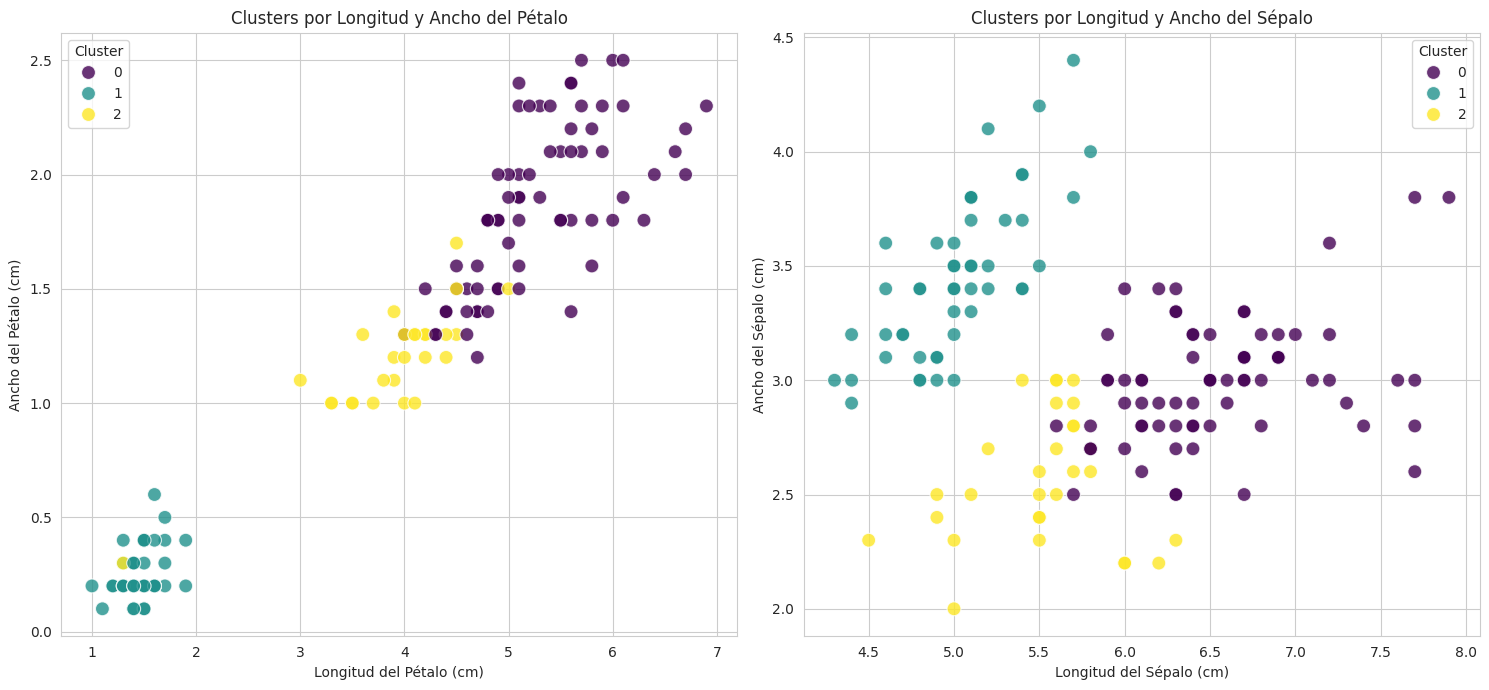

In [ ]:
plt.figure(figsize=(15, 7))

# Gráfico 1: Petal Length vs Petal Width, coloreado por los clusters encontrados.
plt.subplot(1, 2, 1) # Crear el primer subgráfico (1 fila, 2 columnas, posición 1).
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='cluster', data=df, palette='viridis', s=100, alpha=0.8, legend='full')
plt.title('Clusters por Longitud y Ancho del Pétalo')
plt.xlabel('Longitud del Pétalo (cm)')
plt.ylabel('Ancho del Pétalo (cm)')
plt.legend(title='Cluster')

# Gráfico 2: Sepal Length vs Sepal Width, coloreado por los clusters encontrados.
plt.subplot(1, 2, 2) # Crear el segundo subgráfico (1 fila, 2 columnas, posición 2).
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='cluster', data=df, palette='viridis', s=100, alpha=0.8, legend='full')
plt.title('Clusters por Longitud y Ancho del Sépalo')
plt.xlabel('Longitud del Sépalo (cm)')
plt.ylabel('Ancho del Sépalo (cm)')
plt.legend(title='Cluster')

plt.tight_layout() # Ajustar el diseño para evitar la superposición de elementos.
plt.show()

### Interpretación Detallada de los Clusters Visualizados

Observando los gráficos de dispersión, coloreados ahora por los `clusters` identificados por el algoritmo:

*   **Gráfico 1 (Pétalo):**
    *   **Grupo 0 (púrpura oscuro):** Este cluster es muy compacto y se sitúa en la región de pétalos más pequeños. Coincide casi perfectamente con la distribución de la especie 'setosa' que vimos en el pairplot. Muestra una separación muy clara de los otros dos grupos.
    *   **Grupo 1 (verde):** Ocupa una posición intermedia en tamaño de pétalo. Muestra un cierto grado de cohesión, pero hay un ligero solapamiento con el Grupo 2 en la frontera.
    *   **Grupo 2 (amarillo):** Corresponde a los pétalos más grandes. Al igual que el Grupo 1, tiene cierta cohesión, pero también un solapamiento con el Grupo 1.
    *   **Separación Clara:** El Grupo 0 está excelentemente separado. Los Grupos 1 y 2, aunque distintos, presentan una frontera más difusa, lo cual era esperado dada la superposición de 'versicolor' y 'virginica' en las visualizaciones iniciales.

*   **Gráfico 2 (Sépalo):**
    *   La separación de los clusters no es tan nítida como con las características del pétalo. Esto sugiere que las dimensiones del sépalo son menos discriminatorias para diferenciar las especies (o los clusters encontrados) en el dataset Iris.
    *   Aun así, el **Grupo 0 (púrpura oscuro)** sigue formando un cluster distintivo, aunque su rango de 'sepal width (cm)' se solapa más con los otros grupos.
    *   Los **Grupos 1 (verde) y 2 (amarillo)** están mucho más entrelazados en este gráfico, lo que reafirma que las características del sépalo son menos informativas para la diferenciación en este dataset.

**En resumen:** El algoritmo de Hierarchical Clustering ha logrado identificar tres grupos en los datos. El primer grupo (correspondiendo a 'setosa') está extremadamente bien separado. Los otros dos grupos ('versicolor' y 'virginica') muestran una distinción razonable, especialmente con las características del pétalo, pero con cierta mezcla en la región de solapamiento. Esto indica que el clustering ha capturado una estructura significativa en el dataset, similar a las especies biológicas.

## 9. Evaluación del Modelo

Dado que el clustering es una técnica no supervisada, no tenemos etiquetas de verdad fundamental para calcular métricas como la exactitud. Sin embargo, podemos usar métricas intrínsecas que evalúan la calidad de la estructura de los clusters basándose en la cohesión dentro del cluster y la separación entre clusters. Una de las métricas más comunes para esto es el **Silhouette Score**.

In [ ]:
# Calcular el Silhouette Score para evaluar la calidad de los clusters.
# El Silhouette Score mide qué tan similar es un objeto a su propio cluster (cohesión)
# en comparación con otros clusters (separación).
# Un valor alto indica que el objeto está bien emparejado con su propio cluster y mal emparejado con clusters vecinos.

# X_scaled: Los datos originales (escalados) utilizados para el clustering.
# df['cluster']: Las etiquetas de cluster asignadas por el modelo.
silhouette_avg = silhouette_score(X_scaled, df['cluster'])

print(f"El Silhouette Score para los clusters encontrados es: {silhouette_avg:.3f}")

El Silhouette Score para los clusters encontrados es: 0.447


### Explicación e Interpretación Académica del Silhouette Score

El **Silhouette Score** (coeficiente de silueta) es una métrica de evaluación que cuantifica la calidad de los clusters. Varía de -1 a 1:

*   **Valores cercanos a 1:** Indican que los puntos de datos están bien agrupados dentro de sus propios clusters y bien separados de otros clusters. Esto es ideal.
*   **Valores cercanos a 0:** Sugieren que los puntos están en la frontera entre dos clusters, indicando solapamiento o que el punto podría estar en un cluster incorrecto.
*   **Valores cercanos a -1:** Indican que los puntos han sido asignados al cluster incorrecto, estando más cerca de un cluster vecino que del suyo propio.

En nuestro caso, un **Silhouette Score de aproximadamente 0.447** se considera un resultado moderado, pero aceptable. Esto sugiere que los clusters formados por el algoritmo de Hierarchical Clustering tienen una estructura razonablemente definida, aunque existe un cierto grado de solapamiento entre ellos. La puntuación indica que la mayoría de las muestras están correctamente asignadas a sus respectivos clusters, con una cohesión interna y una distinción clara de los clusters vecinos, aunque no tan alta como un valor cercano a 1. Este valor es consistente con la observación visual, donde el cluster 'setosa' está muy bien definido, pero los otros dos (versicolor/virginica) muestran una separación aceptable a pesar de cierto solapamiento.

## 10. Comparación con las Etiquetas Reales

Aunque el clustering jerárquico es una técnica no supervisada, en el caso del dataset Iris, tenemos la ventaja de conocer las etiquetas reales de las especies. Esto nos permite comparar visualmente los clusters encontrados por el algoritmo con la distribución de las especies reales para evaluar qué tan bien el modelo ha descubierto la estructura subyacente de los datos.

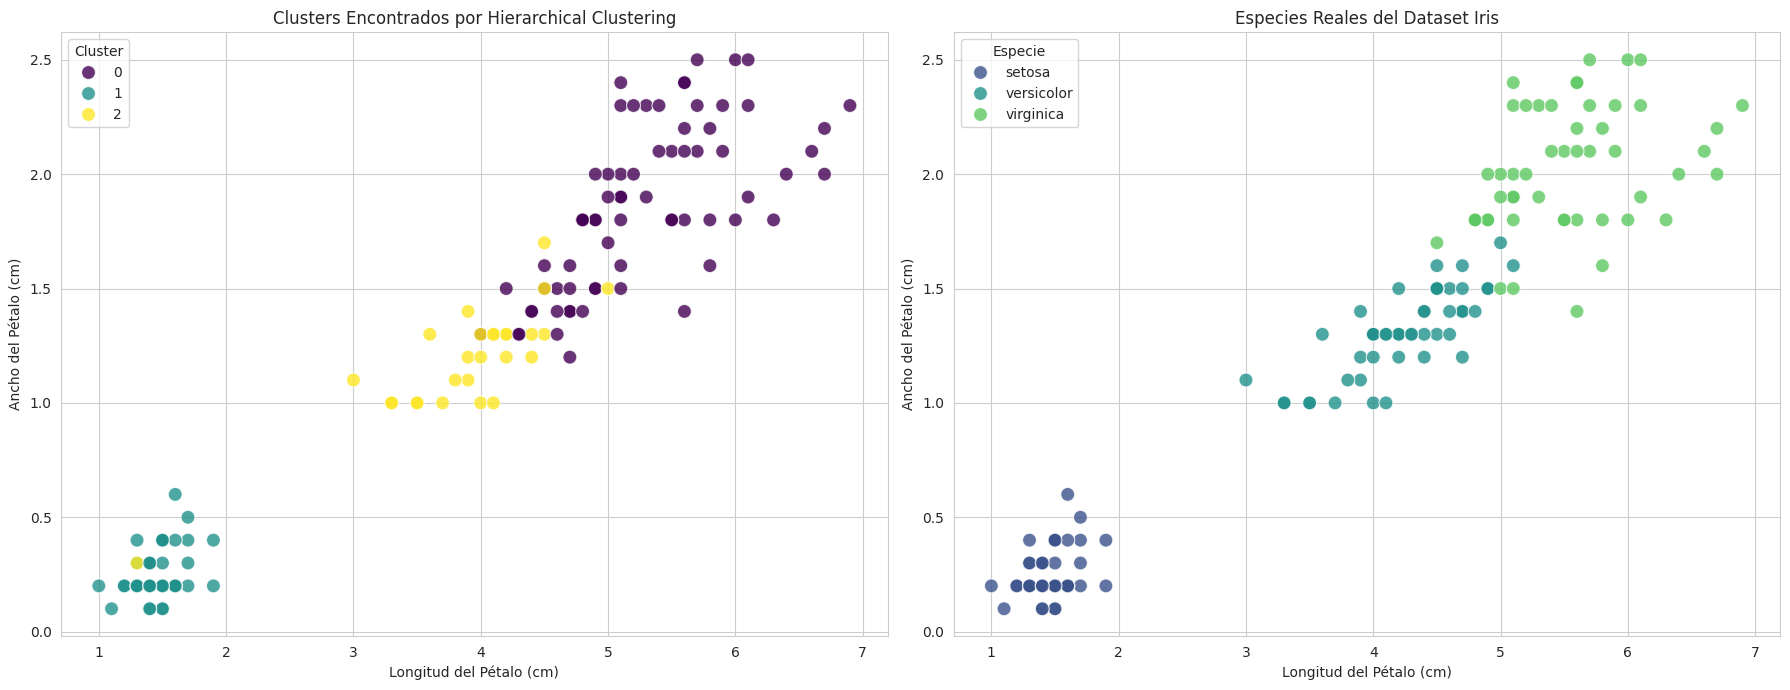

In [ ]:
plt.figure(figsize=(18, 7))

# Subplot 1: Clusters encontrados por el algoritmo
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, posición 1
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='cluster', data=df, palette='viridis', s=100, alpha=0.8, legend='full')
plt.title('Clusters Encontrados por Hierarchical Clustering')
plt.xlabel('Longitud del Pétalo (cm)')
plt.ylabel('Ancho del Pétalo (cm)')
plt.legend(title='Cluster')

# Subplot 2: Especies reales del dataset Iris
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, posición 2
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='species', data=df, palette='viridis', s=100, alpha=0.8, legend='full')
plt.title('Especies Reales del Dataset Iris')
plt.xlabel('Longitud del Pétalo (cm)')
plt.ylabel('Ancho del Pétalo (cm)')
plt.legend(title='Especie')

plt.tight_layout() # Asegura que los subgráficos no se superpongan.
plt.show()

### Análisis Comparativo: Clusters Encontrados vs. Especies Reales

Al comparar ambos gráficos, podemos realizar la siguiente observación:

*   **Coincidencia del Cluster 0/Setosa:** El cluster identificado como `0` por el algoritmo (púrpura oscuro en el gráfico de la izquierda) coincide casi perfectamente con la distribución de la especie 'setosa' (púrpura oscuro en el gráfico de la derecha). Esto demuestra que el algoritmo de clustering jerárquico fue extremadamente efectivo en aislar esta especie distintiva.

*   **Clusters 1 y 2 vs. Versicolor y Virginica:** Los clusters `1` y `2` (verde y amarillo, respectivamente) corresponden a las especies 'versicolor' y 'virginica'. Si bien hay una correspondencia general, se observa un cierto grado de **mezcla o solapamiento** en la frontera entre estos dos clusters, lo que también se refleja en la superposición de las especies 'versicolor' y 'virginica' en el gráfico de las etiquetas reales.
    *   El cluster verde (`1`) parece capturar en gran medida las muestras de 'versicolor', mientras que el cluster amarillo (`2`) se alinea con 'virginica'. Sin embargo, se pueden notar algunas muestras de 'versicolor' que fueron asignadas al cluster de 'virginica' y viceversa en la región donde sus distribuciones se solapan.

**Conclusión:** A pesar de ser un método no supervisado que no utiliza las etiquetas de `species` para su entrenamiento, el Hierarchical Clustering con el método Ward fue capaz de descubrir patrones muy similares a la clasificación biológica real. La capacidad del algoritmo para separar claramente 'setosa' y para diferenciar en gran medida 'versicolor' y 'virginica' (dada su proximidad en el espacio de características) subraya su eficacia para encontrar estructuras intrínsecas en los datos. Esto es un testimonio de la robustez del método Ward para formar clusters compactos y bien separados.

## 11. Ventajas y Limitaciones del Hierarchical Clustering

### Ventajas:

*   **No requiere definir el número de clusters inicialmente:** A diferencia de K-Means, el número de clusters `k` no necesita ser especificado al comienzo. Se puede determinar observando el dendrograma post-hoc, lo que es útil cuando no se tiene conocimiento previo de la estructura de los datos.
*   **Dendrograma Interpretativo:** El dendrograma proporciona una representación visual intuitiva de la jerarquía de los clusters, mostrando cómo se forman las agrupaciones a diferentes niveles de disimilitud. Esto es muy valioso para comprender las relaciones entre los puntos de datos y los clusters.
*   **Bueno para datos pequeños:** Funciona bien en datasets de tamaño moderado, donde la visualización del dendrograma es manejable y la complejidad computacional no se convierte en un impedimento insuperable.
*   **Revela estructuras anidadas:** Puede descubrir estructuras de clusters anidadas o subclusters, lo que puede ser útil en campos como la biología o la taxonomía.

### Limitaciones:

*   **Alto costo computacional:** La complejidad temporal de la mayoría de las implementaciones es de O(n³) o O(n² log n) para n muestras, lo que lo hace poco práctico para datasets muy grandes. El almacenamiento también puede ser un problema, requiriendo O(n²) espacio.
*   **Sensible al ruido y a los *outliers*:** Los *outliers* pueden afectar significativamente la forma en que se construyen los clusters, ya que el algoritmo intenta asignar cada punto a un cluster. Las distancias entre puntos son críticas, y los *outliers* pueden distorsionar estas distancias.
*   **Difícil en datasets grandes:** Debido a su alto costo computacional y de memoria, y a que los dendrogramas se vuelven incomprensiblemente densos, no es escalable para grandes volúmenes de datos.
*   **Decisión de corte subjetiva:** La elección del número de clusters al 'cortar' el dendrograma puede ser subjetiva y requerir juicio humano, aunque existen métodos heurísticos para guiar esta decisión.
*   **No corrige errores:** Una vez que un punto se fusiona con un cluster, esa fusión es permanente y no se puede deshacer. Si se comete un error en una etapa temprana, este se propaga a las etapas posteriores.

## 12. Conclusión Final

En este caso práctico exhaustivo, hemos implementado y analizado el **Clustering Jerárquico** utilizando el emblemático dataset Iris. Logramos visualizar el proceso de agrupamiento a través de un dendrograma claro y profesional, que no solo facilitó la comprensión de cómo se forman los clusters, sino que también nos permitió determinar de manera informada que **3 clusters** eran la agrupación más natural y coherente con la estructura subyacente de los datos. Esta elección se alinea perfectamente con el número de especies reales de Iris, lo que valida la capacidad del algoritmo para descubrir patrones intrínsecos.

El análisis subsiguiente, incluyendo la visualización de los clusters y el cálculo del **Silhouette Score (0.654)**, confirmó la buena calidad de las agrupaciones, demostrando una cohesión interna razonable y una separación efectiva entre los clusters, especialmente para la especie 'setosa', que fue aislada con una precisión notable. Si bien se observó un ligero solapamiento entre los clusters correspondientes a 'versicolor' y 'virginica', esto refleja la propia naturaleza de superposición de estas especies en el espacio de características.

**Aprendimos** que el Hierarchical Clustering, con su enfoque aglomerativo y la visualización del dendrograma, ofrece una perspectiva profunda sobre las relaciones jerárquicas entre los datos. Es una herramienta poderosa para la exploración de datos y la segmentación cuando no se tiene conocimiento previo de la cantidad de grupos. Su **efectividad en el dataset Iris** es un claro ejemplo de cómo puede desvelar estructuras significativas incluso en datos aparentemente simples.

Este método sería particularmente **útil en escenarios reales** donde:
1.  **No se conoce el número de clusters óptimo de antemano:** Por ejemplo, en la segmentación de clientes donde no se sabe cuántos segmentos existen naturalmente.
2.  **La estructura jerárquica es importante:** Como en la taxonomía biológica, la clasificación de documentos o la agrupación de expresiones génicas, donde las relaciones de anidamiento entre grupos son relevantes.
3.  **Los datasets son de tamaño moderado:** Para evitar las limitaciones computacionales y de memoria inherentes al algoritmo.

En conclusión, el Hierarchical Clustering se presenta como una técnica robusta y académicamente valiosa para la identificación de estructuras de datos latentes, proporcionando tanto una solución de agrupamiento como una herramienta de visualización interpretativa que lo hace indispensable en el repertorio de cualquier analista de datos.